In [1]:
!pip install scanpy

In [2]:
import scanpy as sc

adata = sc.datasets.pbmc3k()

print(adata)

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)


In [3]:
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None, log1p=False)

print(adata.obs.head())

                  n_genes_by_counts  total_counts
index                                            
AAACATACAACCAC-1                781        2421.0
AAACATTGAGCTAC-1               1352        4903.0
AAACATTGATCAGC-1               1131        3149.0
AAACCGTGCTTCCG-1                960        2639.0
AAACCGTGTATGCG-1                522         981.0


In [4]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print(adata.obs.head())

                  n_genes_by_counts  total_counts  total_counts_mt  \
index                                                                
AAACATACAACCAC-1                781        2421.0             73.0   
AAACATTGAGCTAC-1               1352        4903.0            186.0   
AAACATTGATCAGC-1               1131        3149.0             28.0   
AAACCGTGCTTCCG-1                960        2639.0             46.0   
AAACCGTGTATGCG-1                522         981.0             12.0   

                  pct_counts_mt  
index                            
AAACATACAACCAC-1       3.015283  
AAACATTGAGCTAC-1       3.793596  
AAACATTGATCAGC-1       0.889171  
AAACCGTGCTTCCG-1       1.743085  
AAACCGTGTATGCG-1       1.223242  


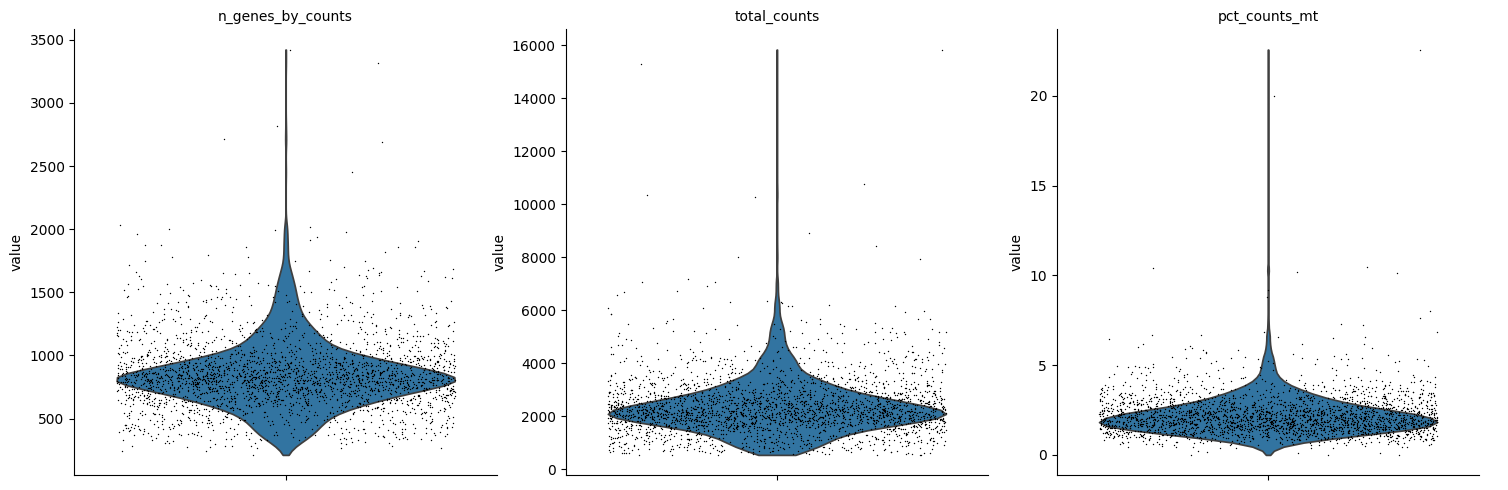

In [5]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

In [6]:
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(adata)

View of AnnData object with n_obs × n_vars = 2638 × 32738
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mt'
    layers: None (.X)


In [7]:
adata = adata.copy()

In [8]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [9]:
adata.raw = adata

In [10]:
print(adata.X[:5, :5])

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 0 stored elements and shape (5, 5)>


In [11]:
print("Max value in data:", adata.X.max())
print("Min value in data:", adata.X.min())

Max value in data: 7.4685445
Min value in data: 0.0


In [12]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

print(adata.var.head())

                     gene_ids  n_cells_by_counts  mean_counts  \
index                                                           
MIR1302-10    ENSG00000243485                  0          0.0   
FAM138A       ENSG00000237613                  0          0.0   
OR4F5         ENSG00000186092                  0          0.0   
RP11-34P13.7  ENSG00000238009                  0          0.0   
RP11-34P13.8  ENSG00000239945                  0          0.0   

              pct_dropout_by_counts  total_counts     mt  highly_variable  \
index                                                                       
MIR1302-10                    100.0           0.0  False            False   
FAM138A                       100.0           0.0  False            False   
OR4F5                         100.0           0.0  False            False   
RP11-34P13.7                  100.0           0.0  False            False   
RP11-34P13.8                  100.0           0.0  False            False   

    

In [13]:
print(adata.var[adata.var['highly_variable'] == True].head())

                      gene_ids  n_cells_by_counts  mean_counts  \
index                                                            
TNFRSF4        ENSG00000186827                155     0.077407   
CPSF3L         ENSG00000127054                202     0.094815   
ATAD3C         ENSG00000215915                  9     0.009259   
RP11-345P4.10  ENSG00000272004                  2     0.000741   
RER1           ENSG00000157916                608     0.298148   

               pct_dropout_by_counts  total_counts     mt  highly_variable  \
index                                                                        
TNFRSF4                    94.259259         209.0  False             True   
CPSF3L                     92.518519         256.0  False             True   
ATAD3C                     99.666667          25.0  False             True   
RP11-345P4.10              99.925926           2.0  False             True   
RER1                       77.481481         805.0  False            

In [14]:
adata = adata[:, adata.var.highly_variable]

print(adata)

View of AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: None (.X)


In [15]:
adata = adata.copy()

In [16]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [17]:
print(adata.obsm['X_pca'].shape)

(2638, 50)


In [18]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

In [19]:
!pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 81.4 MB/s eta 0:00:00


In [20]:
sc.tl.leiden(adata, flavor='igraph', n_iterations=2, directed=False)

print(adata.obs['leiden'].value_counts())

leiden
3    607
2    549
6    468
1    342
0    299
4    169
5    153
7     36
8     15
Name: count, dtype: int64


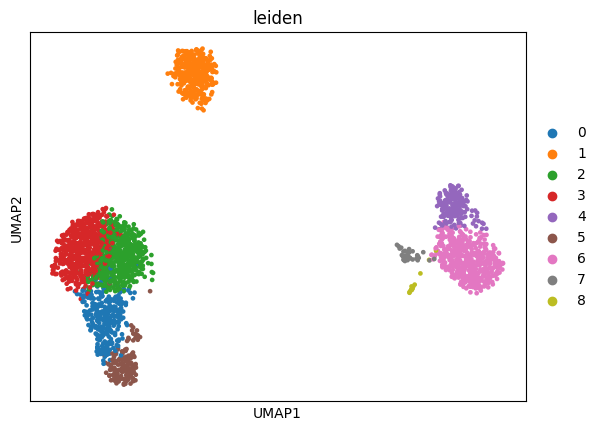

In [21]:
sc.tl.umap(adata)

sc.pl.umap(adata, color='leiden')

In [22]:
print(adata)

AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: None (.X)


In [23]:
adata_full = sc.datasets.pbmc3k()
sc.pp.normalize_total(adata_full, target_sum=1e4)
sc.pp.log1p(adata_full)

markers = ['CD3D', 'CD79A', 'CD14', 'NKG7']

for gene in markers:
    adata.obs[gene] = adata_full[adata.obs_names, gene].X.toarray().flatten()

print(adata.obs[markers].head())

                      CD3D     CD79A  CD14      NKG7
index                                               
AAACATACAACCAC-1  2.863463  0.000000   0.0  0.000000
AAACATTGAGCTAC-1  0.000000  1.962726   0.0  1.111715
AAACATTGATCAGC-1  3.489089  0.000000   0.0  0.000000
AAACCGTGCTTCCG-1  0.000000  0.000000   0.0  1.566387
AAACCGTGTATGCG-1  0.000000  0.000000   0.0  4.728542


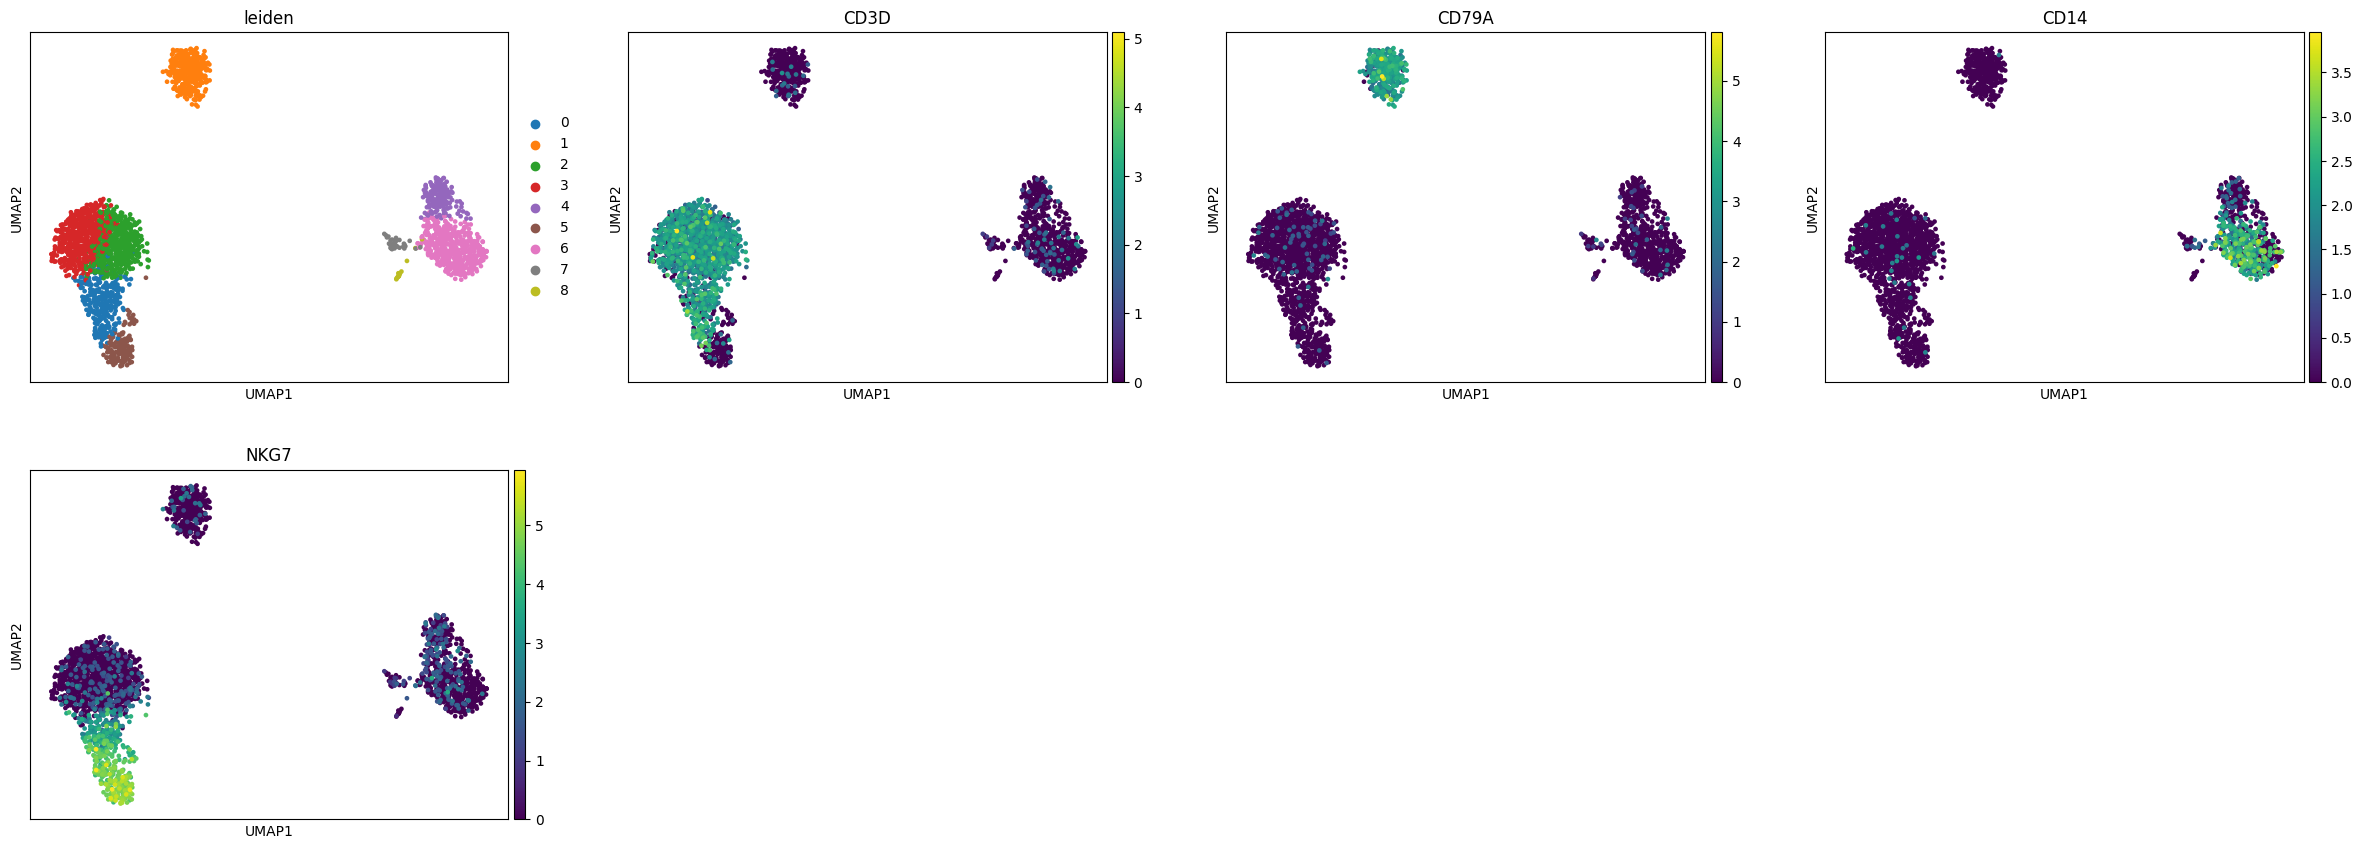

In [24]:
sc.pl.umap(adata, color=['leiden', 'CD3D', 'CD79A', 'CD14', 'NKG7'])

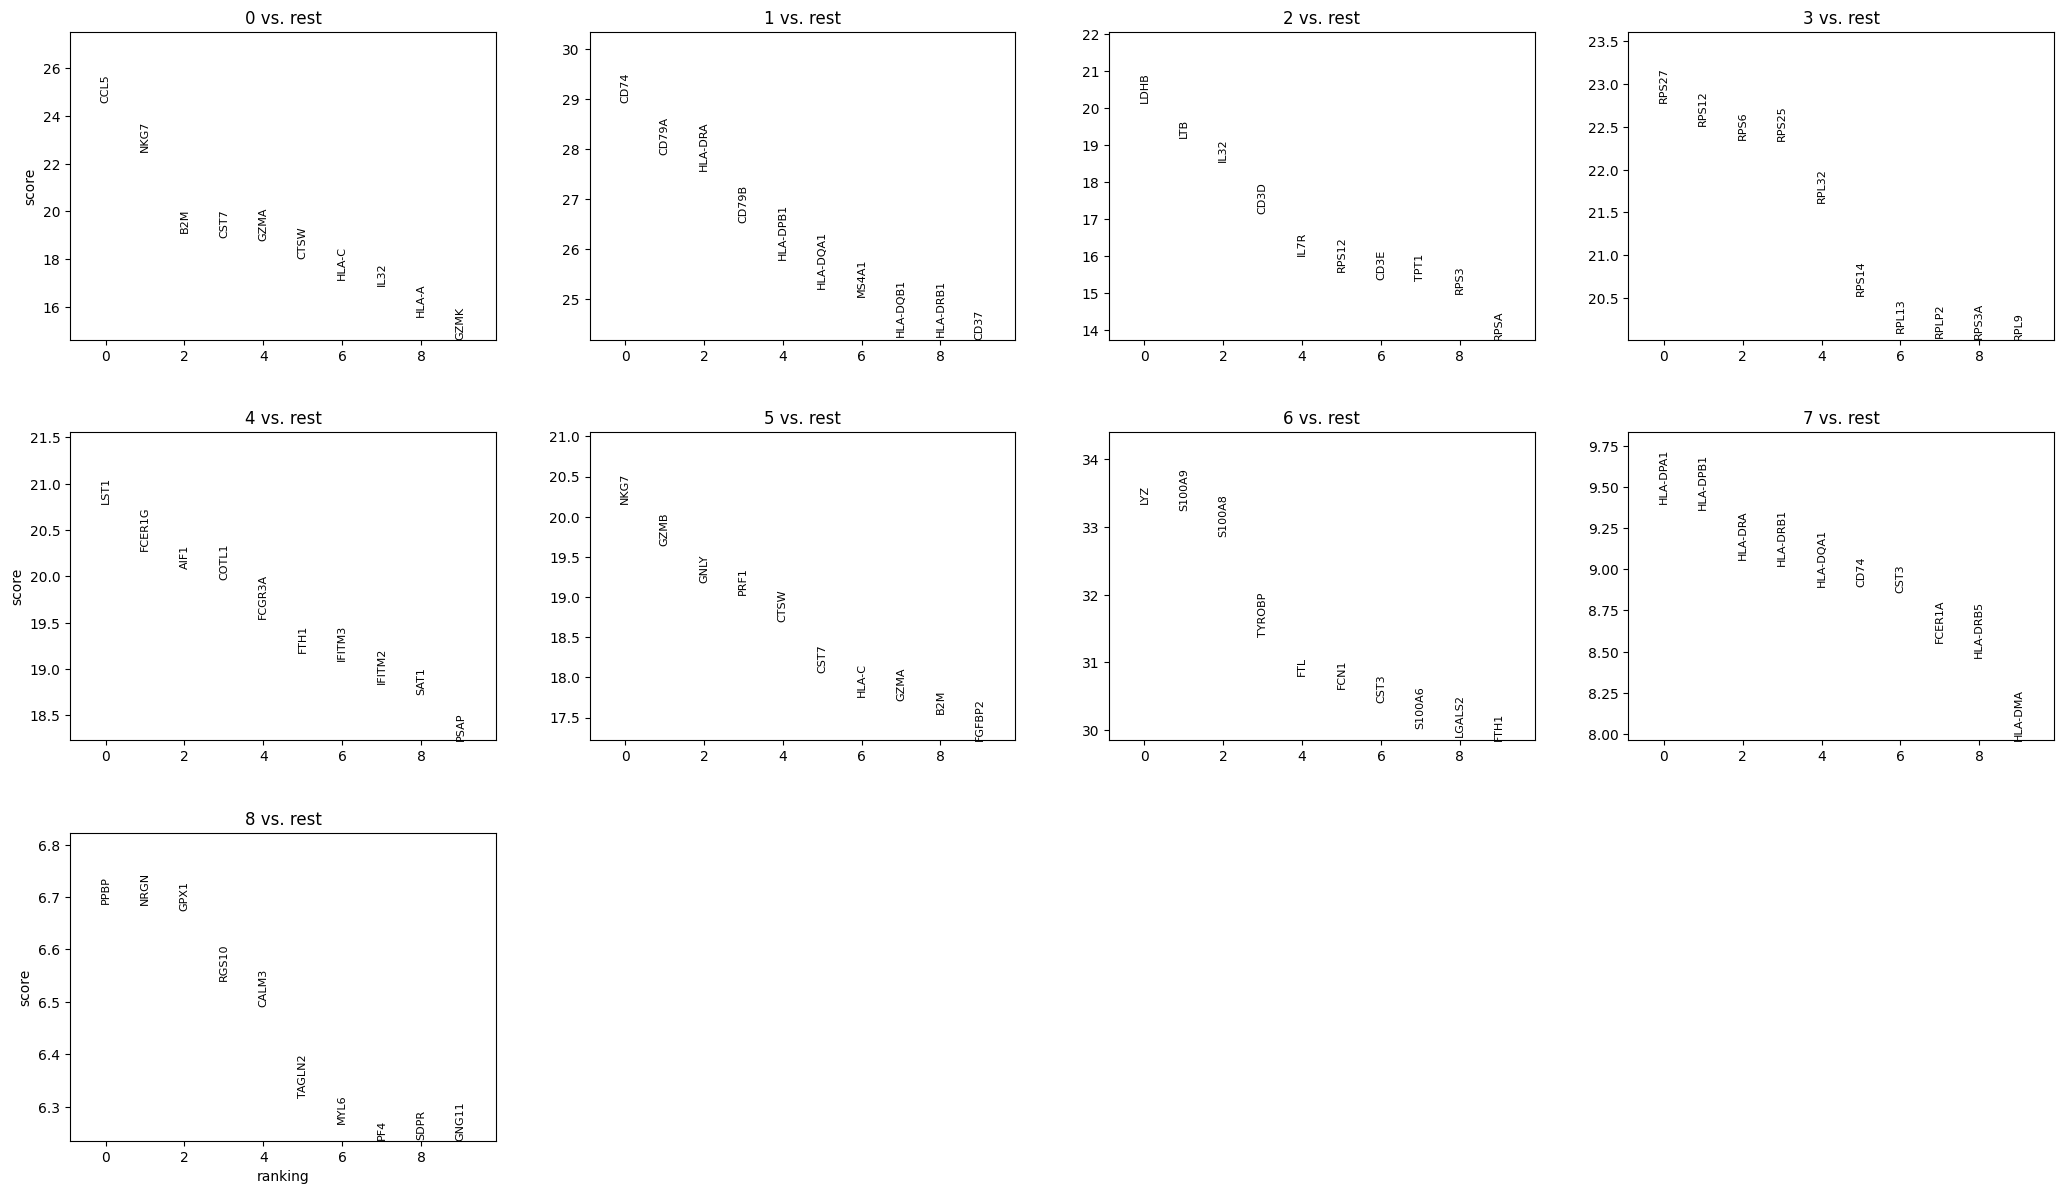

In [25]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon', use_raw=True)

sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

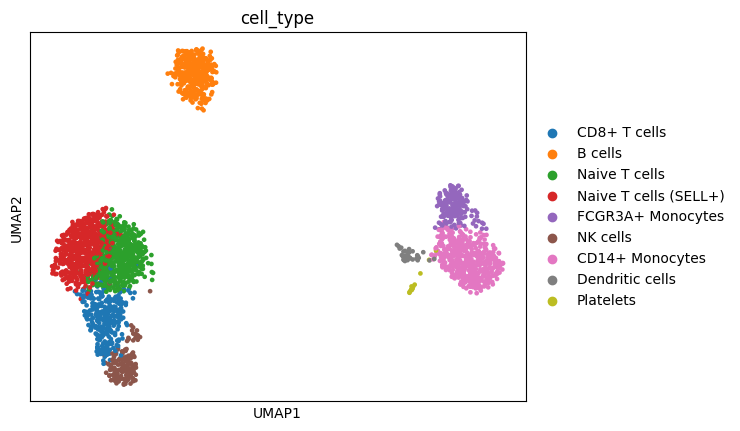

In [35]:
cluster_names = {
    '0': 'CD8+ T cells',
    '1': 'B cells',
    '2': 'Naive T cells',
    '3': 'Naive T cells (SELL+)',
    '4': 'FCGR3A+ Monocytes',
    '5': 'NK cells',
    '6': 'CD14+ Monocytes',
    '7': 'Dendritic cells',
    '8': 'Platelets'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_names)

sc.pl.umap(adata, color='cell_type')

In [37]:
marker_genes = {
    'CD8+ T cells': ['CCL5', 'NKG7', 'GZMA'],
    'B cells': ['CD79A', 'CD79B', 'HLA-DRA'],
    'Naive T cells': ['LTB', 'CD2'],
    'Naive T cells (SELL+)': ['SELL', 'RPS3A'],
    'FCGR3A+ Monocytes': ['FCGR3A', 'FCER1G'],
    'NK cells': ['GNLY', 'GZMB', 'PRF1'],
    'CD14+ Monocytes': ['LYZ', 'S100A8', 'S100A9'],
    'Dendritic cells': ['HLA-DPA1', 'FCER1A', 'CST3'],
    'Platelets': ['PPBP', 'PF4']
}

print(marker_genes)

{'CD8+ T cells': ['CCL5', 'NKG7', 'GZMA'], 'B cells': ['CD79A', 'CD79B', 'HLA-DRA'], 'Naive T cells': ['LTB', 'CD2'], 'Naive T cells (SELL+)': ['SELL', 'RPS3A'], 'FCGR3A+ Monocytes': ['FCGR3A', 'FCER1G'], 'NK cells': ['GNLY', 'GZMB', 'PRF1'], 'CD14+ Monocytes': ['LYZ', 'S100A8', 'S100A9'], 'Dendritic cells': ['HLA-DPA1', 'FCER1A', 'CST3'], 'Platelets': ['PPBP', 'PF4']}


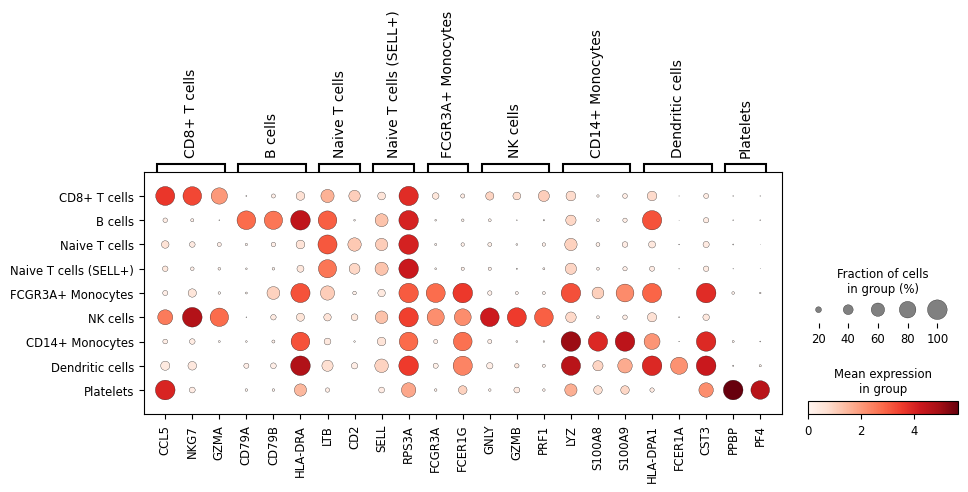

In [38]:
sc.pl.dotplot(adata, marker_genes, groupby='cell_type', use_raw=True)